# Jane Street Partition 8: Final Project Story

This notebook summarizes the complete partition 8 workflow: data preparation, time-based splits, tree baselines, rolling feature engineering, neural experiments, and ensembles. It is report-only: it reads saved JSON/CSV results and does not load parquet data, train models, or download artifacts.

Each row is one anonymized symbol at a particular `date_id` and `time_id`. The model predicts the anonymous return-like target `responder_6`; `weight` controls how much that row matters. Every score shown is the competition-style weighted $R^2$:

$$R^2_w = 1 - \frac{\sum_i w_i(y_i-\hat y_i)^2}{\sum_i w_i y_i^2}$$

A score of 0 equals predicting zero for every row, a positive score improves on that baseline, and a negative score is worse. Scores are small because short-horizon returns are extremely noisy. This study covers partition 8 only, not the full competition dataset.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path('/users/s/a/sakshay/js_kaggle')]
    for candidate in candidates:
        if (candidate / 'logs').exists() and (candidate / 'models').exists():
            return candidate.resolve()
    raise FileNotFoundError('Run this notebook from the repository or notebooks directory.')

PROJECT_ROOT = find_project_root()
LOG_DIR = PROJECT_ROOT / 'logs'
MODEL_DIR = PROJECT_ROOT / 'models'

def load_json(name):
    path = LOG_DIR / name
    if not path.exists():
        raise FileNotFoundError(f'Missing saved report: {path}')
    return json.loads(path.read_text())

BLUE = '#2563eb'
GREEN = '#15803d'
ORANGE = '#d97706'
RED = '#b91c1c'
GRAY = '#64748b'
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.grid': True, 'grid.alpha': 0.22, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'project_root={PROJECT_ROOT}')
print('Report-only notebook: no parquet files or trained model files are loaded.')

project_root=/Users/akshay/Desktop/js_kaggle
Report-only notebook: no parquet files or trained model files are loaded.


## 1. Data and time split

We used only `partition_id=8`. The raw partition contained 6,140,024 rows, 79 anonymous `feature_` columns, `responder_6`, `weight`, and the identifiers `date_id`, `time_id`, and `symbol_id`. The IDs preserve order and grouping but do not reveal real dates or asset names. After cleaning, 5,538,291 rows remained.

The split was chronological, not randomized. Training dates fit the models, validation dates selected features and hyperparameters, and the later test dates compared the selected models. This avoids training on future observations and then evaluating on the past.

,split,rows,date_min,date_max,unique_dates
0,Train,"4,162,125",1360,1489,125
1,Validation,"680,149",1490,1509,20
2,Test,"696,017",1510,1529,20


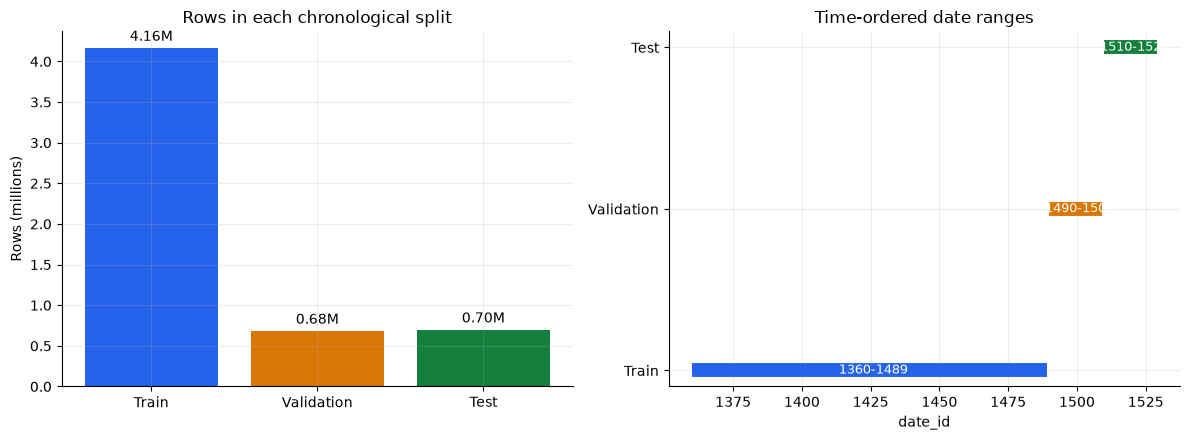

In [2]:
top20_lgbm = load_json('train_top20_lgbm_report.json')
ensemble_report = load_json('ensemble_focused_mlp_xgb_report.json')

dataset_summary = pd.DataFrame([
    {'split': 'Train', 'rows': 4_162_125, 'date_min': 1360, 'date_max': 1489, 'unique_dates': 125},
    {'split': 'Validation', 'rows': 680_149, 'date_min': 1490, 'date_max': 1509, 'unique_dates': 20},
    {'split': 'Test', 'rows': 696_017, 'date_min': 1510, 'date_max': 1529, 'unique_dates': 20},
])
display(dataset_summary.style.format({'rows': '{:,.0f}'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = [BLUE, ORANGE, GREEN]
bars = axes[0].bar(dataset_summary['split'], dataset_summary['rows'] / 1e6, color=colors)
axes[0].bar_label(bars, fmt='%.2fM', padding=3)
axes[0].set_ylabel('Rows (millions)')
axes[0].set_title('Rows in each chronological split')

for row, color in zip(dataset_summary.itertuples(), colors):
    axes[1].plot([row.date_min, row.date_max], [row.split, row.split], linewidth=10, color=color, solid_capstyle='butt')
    axes[1].text((row.date_min + row.date_max) / 2, row.split, f'  {row.date_min}-{row.date_max}', va='center', color='white', ha='center', fontsize=9)
axes[1].set_xlabel('date_id')
axes[1].set_title('Time-ordered date ranges')
plt.tight_layout()
plt.show()

The cleaned dataset spans 165 observed dates between `date_id=1360` and `1529`. Features with at most 15 distinct values were inspected as categorical candidates; this flagged `feature_09`, `feature_10`, and `feature_11`. The tree models ultimately treated `symbol_id` and `feature_11` as categorical. None mapped cleanly enough to symbols to justify calling it an asset-class label.

## 2. Cleaning the partition

The 1.5 GB raw parquet could not be loaded safely on a laptop. Cleaning therefore ran as a streaming PyArrow job on Longleaf with batches of 8,192 rows. Each batch selected only the required columns, dropped rows missing `responder_6`, `weight`, or any feature, cast continuous columns to `float32`, preserved discrete columns with compact integer types, and wrote one compressed parquet incrementally. No full cleaned DataFrame was held in memory.

,status,rows,share
0,Kept,"5,538,291",90.20%
1,Dropped for missing values,"601,733",9.80%


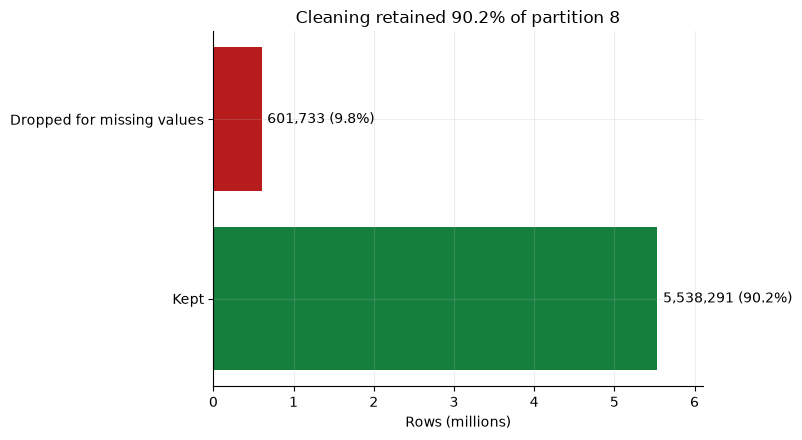

In [3]:
cleaning = pd.DataFrame({
    'status': ['Kept', 'Dropped for missing values'],
    'rows': [5_538_291, 601_733],
})
cleaning['share'] = cleaning['rows'] / cleaning['rows'].sum()
display(cleaning.style.format({'rows': '{:,.0f}', 'share': '{:.2%}'}))

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(cleaning['status'], cleaning['rows'] / 1e6, color=[GREEN, RED])
ax.bar_label(bars, labels=[f'{v:,.0f} ({s:.1%})' for v, s in zip(cleaning['rows'], cleaning['share'])], padding=4)
ax.set_xlabel('Rows (millions)')
ax.set_title('Cleaning retained 90.2% of partition 8')
ax.set_xlim(0, 6.1)
plt.tight_layout()
plt.show()

Dropping complete rows removed 601,733 observations, or 9.80% of the partition. This gave every model the same clean input and avoided treating zero as market information. The trade-off is complete-case bias: if missingness itself contains signal, this cleaning rule discards it.

## Earlier exploratory work (different data scope)

Before the partition 8 pipeline, the Kaggle notebooks explored earlier partitions. EDA found 39 anonymized symbols, 79 features, nine responders, heavy-tailed `responder_6`, changing volatility, and much heavier missingness in early dates. Partition 5 trained several models and partition 6 acted as a later check.

The main early model combined correlated raw features, market-wide averages at each date/time, and long symbol-level rolling statistics. We also tried **residual models**, which learn a second model for the first model's errors, and **PCA factors**, which compress correlated inputs into a smaller set of directions before prediction. Ridge tested a linear factor relationship; LightGBM tested a nonlinear one.

,experiment,valid,test,note
0,Global LightGBM,0.007950,0.005559,raw + market averages + rolling
1,XGBoost,0.001577,not recorded,early tree comparison
2,Global + global residual,0.004645,0.005550,second model fit residuals
3,Symbol residual models,not recorded,0.001538,separate residual models for 4 symbols
4,Ridge on 10 PCA factors,0.004479,not recorded,linear factor model
5,LightGBM on 10 PCA factors,0.006433,not recorded,nonlinear factor model
6,LightGBM on 20 PCA factors,0.009243,0.009248,test used first 100k partition-6 rows
7,LightGBM on 30 PCA factors,0.008710,not recorded,more factors did not help


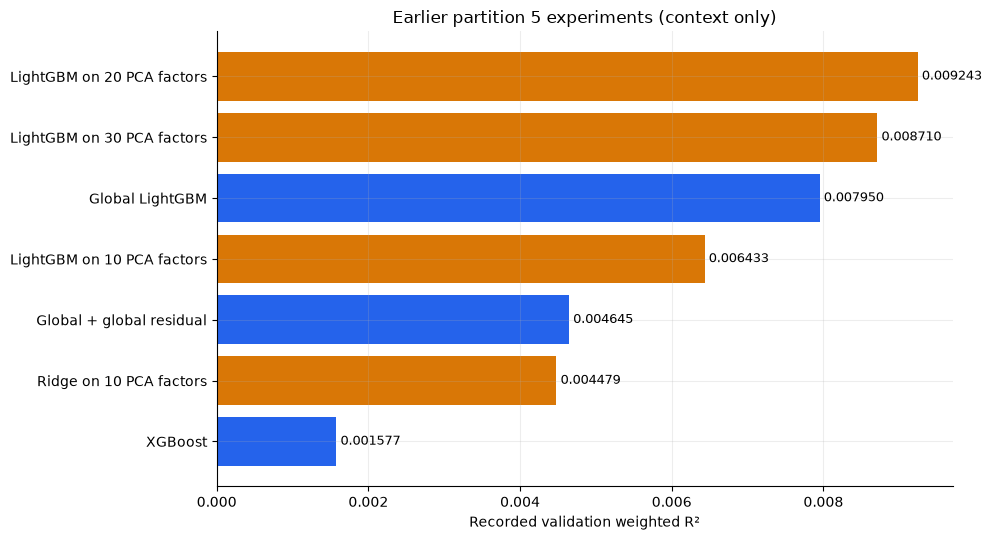

In [4]:
earlier_results = pd.DataFrame([
    {'experiment': 'Global LightGBM', 'valid': 0.007950, 'test': 0.005559, 'note': 'raw + market averages + rolling'},
    {'experiment': 'XGBoost', 'valid': 0.001577, 'test': np.nan, 'note': 'early tree comparison'},
    {'experiment': 'Global + global residual', 'valid': 0.004645, 'test': 0.005550, 'note': 'second model fit residuals'},
    {'experiment': 'Symbol residual models', 'valid': np.nan, 'test': 0.001538, 'note': 'separate residual models for 4 symbols'},
    {'experiment': 'Ridge on 10 PCA factors', 'valid': 0.004479, 'test': np.nan, 'note': 'linear factor model'},
    {'experiment': 'LightGBM on 10 PCA factors', 'valid': 0.006433, 'test': np.nan, 'note': 'nonlinear factor model'},
    {'experiment': 'LightGBM on 20 PCA factors', 'valid': 0.009243, 'test': 0.009248, 'note': 'test used first 100k partition-6 rows'},
    {'experiment': 'LightGBM on 30 PCA factors', 'valid': 0.008710, 'test': np.nan, 'note': 'more factors did not help'},
])
display(earlier_results.style.format({'valid': '{:.6f}', 'test': '{:.6f}'}, na_rep='not recorded'))

view = earlier_results.dropna(subset=['valid']).sort_values('valid')
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(view['experiment'], view['valid'], color=np.where(view['experiment'].str.contains('PCA'), ORANGE, BLUE))
ax.bar_label(bars, fmt='%.6f', padding=3, fontsize=9)
ax.set_xlabel('Recorded validation weighted R²')
ax.set_title('Earlier partition 5 experiments (context only)')
plt.tight_layout()
plt.show()

The early global LightGBM generalized reasonably; both residual approaches overfit rather than correcting stable structure. Twenty PCA factors were promising, but their test score used only the first 100,000 partition-6 rows and a different feature/data pipeline. These results motivated nonlinear global models and rolling features, but they were not reproduced on partition 8 and are therefore excluded from the final leaderboard.

## 3. Baseline models and feature selection

LightGBM and XGBoost are gradient-boosted decision-tree methods: each new tree tries to correct errors left by the previous trees. They were a practical first choice because trees capture nonlinear interactions, require little scaling, and work well on large tabular datasets.

The first full-feature LightGBM used 79 anonymous features plus `symbol_id` and `time_id`. Total split gain selected the top 20 inputs. Gain is the accumulated reduction in training loss from splits using a feature; it is useful for ranking features within a model, but it is not a causal effect. The exact full-feature score is not in the retained local reports, so it is not reconstructed here.

The selected top-20 set contains 18 anonymous features plus `symbol_id` and `time_id`. Reduced train, validation, and test parquet files then kept those model inputs together with `date_id`, `weight`, and `responder_6`.

Model inputs selected: 20
time_id, symbol_id, feature_08, feature_36, feature_61, feature_04, feature_20, feature_06, feature_24, feature_29, feature_58, feature_23, feature_30, feature_28, feature_31, feature_27, feature_21, feature_11, feature_01, feature_70


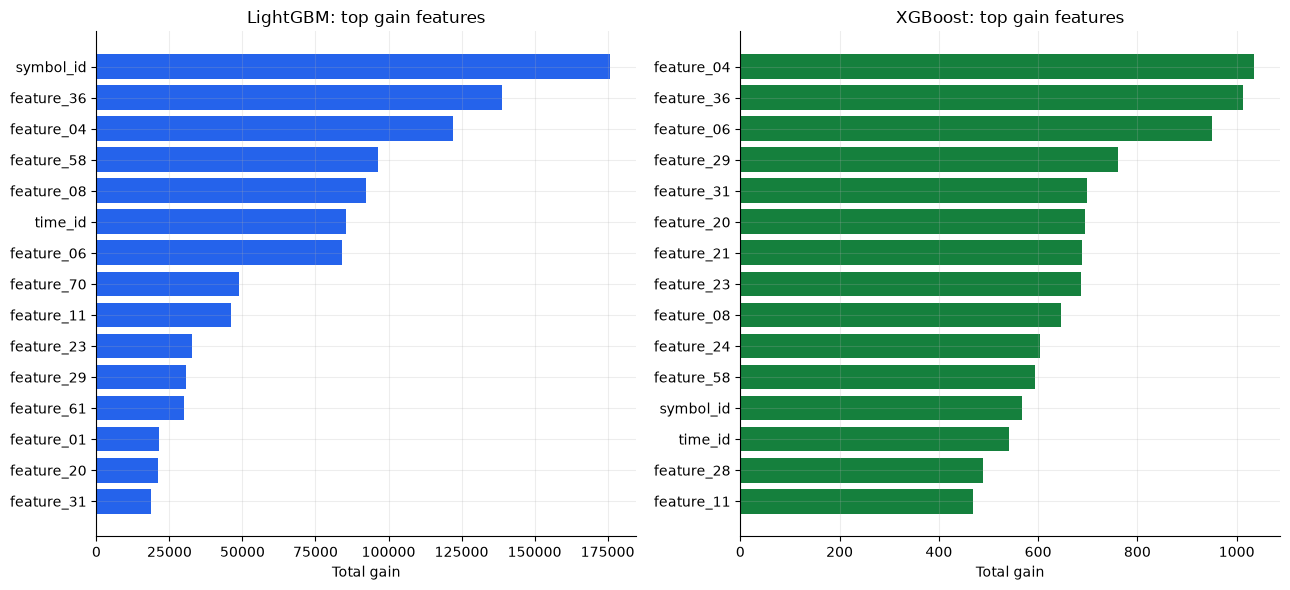

In [5]:
top20_features = top20_lgbm['feature_cols']
print(f'Model inputs selected: {len(top20_features)}')
print(', '.join(top20_features))

lgbm_importance = pd.read_csv(MODEL_DIR / 'lgbm/top20_lgbm/best_feature_importance.csv').head(15)
xgb_importance = pd.read_csv(MODEL_DIR / 'xgboost/top20_xgb/best_feature_importance.csv').head(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, frame, title, color in [
    (axes[0], lgbm_importance, 'LightGBM: top gain features', BLUE),
    (axes[1], xgb_importance, 'XGBoost: top gain features', GREEN),
]:
    view = frame.sort_values('importance_gain')
    ax.barh(view['feature'], view['importance_gain'], color=color)
    ax.set_title(title)
    ax.set_xlabel('Total gain')
plt.tight_layout()
plt.show()

Both tree families consistently relied on `feature_04`, `feature_36`, `feature_06`, `feature_08`, and `feature_58`. `symbol_id` and `time_id` also mattered, confirming that cross-symbol and intraday structure carried signal.

## 4. Tuned LightGBM and XGBoost baselines

Both models minimized weighted squared error and stopped adding trees when validation error stopped improving. We tested a small grid rather than a large search: shallower trees and larger leaves reduce complexity; row/feature subsampling adds randomness; L2 penalties discourage extreme leaf predictions; and a smaller learning rate makes more conservative updates. XGBoost produced the stronger top-20 baseline.

,family,setting,valid_weighted_r2,best_iteration,change_tested
5,XGBoost,shallower,0.005500,150,depth 4
7,XGBoost,slower_learning,0.005438,129,learning rate 0.02
4,XGBoost,baseline,0.005353,71,depth 5
6,XGBoost,more_regularized,0.005289,86,larger child weight; stronger sampling/L2
2,LightGBM,more_regularized,0.004264,29,larger leaves; stronger sampling/L2
1,LightGBM,smaller_leaves,0.004242,48,31 leaves
0,LightGBM,baseline,0.004171,39,64 leaves; light sampling/L2
3,LightGBM,slower_learning,0.003524,37,learning rate 0.02


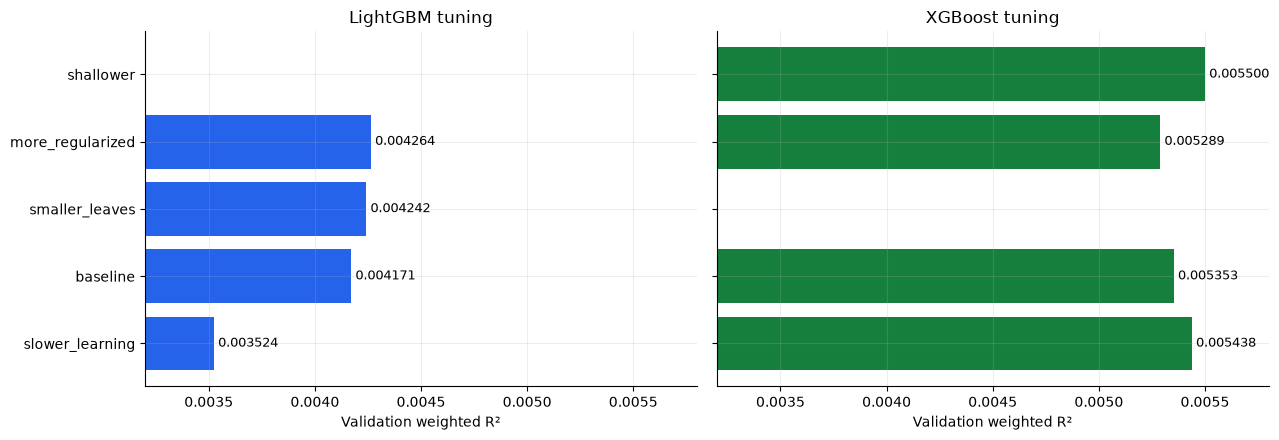

In [6]:
top20_xgb = load_json('train_top20_xgb_report.json')

tree_tuning = []
for family, report in [('LightGBM', top20_lgbm), ('XGBoost', top20_xgb)]:
    for result in report['tuning_results']:
        tree_tuning.append({'family': family, 'setting': result['name'], 'valid_weighted_r2': result['valid_weighted_r2'], 'best_iteration': result['best_iteration']})
tree_tuning = pd.DataFrame(tree_tuning)
setting_detail = {
    ('LightGBM', 'baseline'): '64 leaves; light sampling/L2',
    ('LightGBM', 'smaller_leaves'): '31 leaves',
    ('LightGBM', 'more_regularized'): 'larger leaves; stronger sampling/L2',
    ('LightGBM', 'slower_learning'): 'learning rate 0.02',
    ('XGBoost', 'baseline'): 'depth 5',
    ('XGBoost', 'shallower'): 'depth 4',
    ('XGBoost', 'more_regularized'): 'larger child weight; stronger sampling/L2',
    ('XGBoost', 'slower_learning'): 'learning rate 0.02',
}
tree_tuning['change_tested'] = [setting_detail[(r.family, r.setting)] for r in tree_tuning.itertuples()]
display(tree_tuning.sort_values('valid_weighted_r2', ascending=False).style.format({'valid_weighted_r2': '{:.6f}'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, family, color in zip(axes, ['LightGBM', 'XGBoost'], [BLUE, GREEN]):
    view = tree_tuning[tree_tuning['family'] == family].sort_values('valid_weighted_r2')
    bars = ax.barh(view['setting'], view['valid_weighted_r2'], color=color)
    ax.bar_label(bars, fmt='%.6f', padding=3, fontsize=9)
    ax.set_title(f'{family} tuning')
    ax.set_xlabel('Validation weighted R²')
    ax.set_xlim(0.0032, 0.0058)
plt.tight_layout()
plt.show()

The best top-20 LightGBM reached 0.004264 validation $R^2$. The shallower XGBoost reached 0.005500, about 29% higher on this validation period. XGBoost benefited from `max_depth=4`; LightGBM benefited from larger leaves, more L2 regularization, and stronger row/feature subsampling. Per-boosting-round histories were not saved, so the plots show each configuration's best score and iteration rather than reconstructed training curves.

### Walk-forward stability

A four-fold expanding-window LightGBM check divided validation into consecutive five-date blocks. Fold 1 trained on the original training period; each later fold added earlier validation blocks to training before predicting the next block. This preserves time order and tests whether one aggregate score hides changing market regimes.

,fold,date_block,train_rows,valid_rows,best_iteration,valid_weighted_r2
0,1,1490-1494,"4,162,125","160,919",75,0.006254
1,2,1495-1499,"4,323,044","173,383",33,0.003892
2,3,1500-1504,"4,496,427","170,925",42,0.004225
3,4,1505-1509,"4,667,352","174,922",132,0.009986


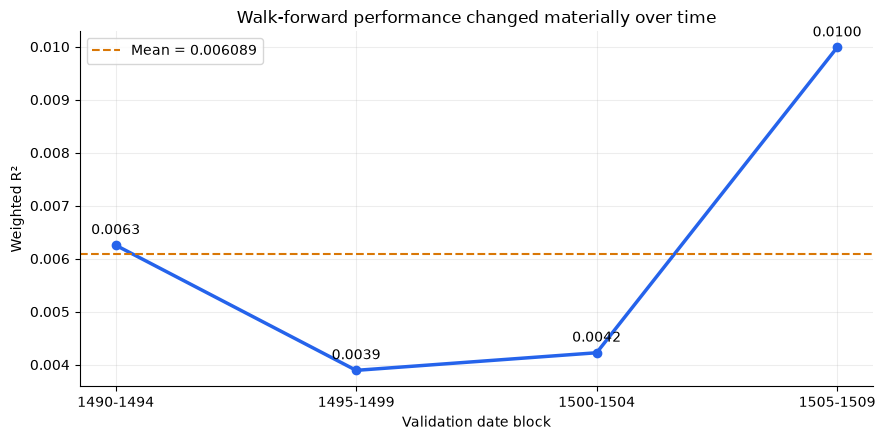

In [7]:
walkforward = load_json('walkforward_top20_lgbm_report.json')
wf = pd.DataFrame(walkforward['results'])
wf['date_block'] = wf['valid_date_min'].astype(str) + '-' + wf['valid_date_max'].astype(str)
display(wf[['fold', 'date_block', 'train_rows', 'valid_rows', 'best_iteration', 'valid_weighted_r2']].style.format({'train_rows': '{:,.0f}', 'valid_rows': '{:,.0f}', 'valid_weighted_r2': '{:.6f}'}))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(wf['date_block'], wf['valid_weighted_r2'], marker='o', linewidth=2.5, color=BLUE)
ax.axhline(walkforward['mean_valid_weighted_r2'], color=ORANGE, linestyle='--', label=f"Mean = {walkforward['mean_valid_weighted_r2']:.6f}")
for row in wf.itertuples():
    ax.annotate(f'{row.valid_weighted_r2:.4f}', (row.date_block, row.valid_weighted_r2), xytext=(0, 8), textcoords='offset points', ha='center')
ax.set_xlabel('Validation date block')
ax.set_ylabel('Weighted R²')
ax.set_title('Walk-forward performance changed materially over time')
ax.legend()
plt.tight_layout()
plt.show()

Fold scores ranged from 0.003892 to 0.009986. The model had positive signal in every block, but its strength was regime-dependent. This justified keeping chronological validation and treating small score differences cautiously.

## 5. Rolling feature engineering

For each symbol, the ten strongest anonymous features received rolling means (recent level) and standard deviations (recent variability) over 5 and 20 observations. Every calculation used `shift(1)` first, so a row used only earlier observations from the same symbol. Unavailable early rolling values were filled with zero. Forty rolling columns were added to the 20 original inputs, producing 60 model inputs.

feature_set,Top 20,Top 20 + rolling
model,,
LightGBM,0.004264,0.004498
XGBoost,0.005500,0.005567


,family,setting,change_tested,valid_weighted_r2,best_iteration
1,LightGBM,more_regularized,larger leaves; stronger sampling/L2,0.004498,51
2,LightGBM,smaller_leaves,31 leaves,0.004391,46
0,LightGBM,baseline,64 leaves; light sampling/L2,0.004237,46
4,XGBoost,shallower,depth 4,0.005567,138
5,XGBoost,more_regularized,larger child weight; stronger sampling/L2,0.005553,126
3,XGBoost,baseline,depth 5,0.005519,96


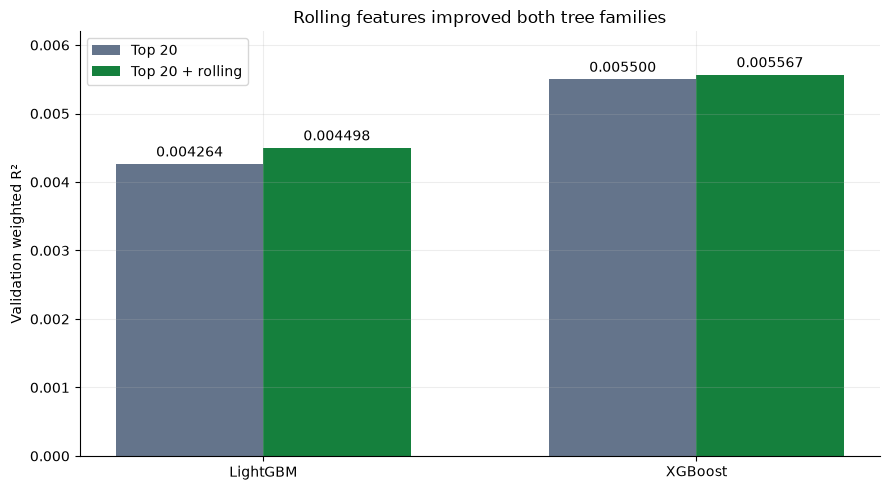

LightGBM relative validation improvement: 5.5%
XGBoost relative validation improvement: 1.2%


In [8]:
rolling_lgbm = load_json('train_rolling_lgbm_report.json')
rolling_xgb = load_json('train_rolling_xgb_report.json')

feature_effect = pd.DataFrame([
    {'model': 'LightGBM', 'feature_set': 'Top 20', 'valid_weighted_r2': top20_lgbm['best']['valid_weighted_r2']},
    {'model': 'LightGBM', 'feature_set': 'Top 20 + rolling', 'valid_weighted_r2': rolling_lgbm['best']['valid_weighted_r2']},
    {'model': 'XGBoost', 'feature_set': 'Top 20', 'valid_weighted_r2': top20_xgb['best']['valid_weighted_r2']},
    {'model': 'XGBoost', 'feature_set': 'Top 20 + rolling', 'valid_weighted_r2': rolling_xgb['best']['valid_weighted_r2']},
])
display(feature_effect.pivot(index='model', columns='feature_set', values='valid_weighted_r2').style.format('{:.6f}'))

rolling_tuning = []
for family, report in [('LightGBM', rolling_lgbm), ('XGBoost', rolling_xgb)]:
    for result in report['tuning_results']:
        rolling_tuning.append({
            'family': family,
            'setting': result['name'],
            'change_tested': setting_detail.get((family, result['name']), result['name']),
            'valid_weighted_r2': result['valid_weighted_r2'],
            'best_iteration': result['best_iteration'],
        })
rolling_tuning = pd.DataFrame(rolling_tuning)
display(rolling_tuning.sort_values(['family', 'valid_weighted_r2'], ascending=[True, False]).style.format({'valid_weighted_r2': '{:.6f}'}))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(2)
width = 0.34
base = feature_effect[feature_effect['feature_set'] == 'Top 20']['valid_weighted_r2'].to_numpy()
roll = feature_effect[feature_effect['feature_set'] == 'Top 20 + rolling']['valid_weighted_r2'].to_numpy()
bars1 = ax.bar(x - width / 2, base, width, label='Top 20', color=GRAY)
bars2 = ax.bar(x + width / 2, roll, width, label='Top 20 + rolling', color=GREEN)
ax.bar_label(bars1, fmt='%.6f', padding=3)
ax.bar_label(bars2, fmt='%.6f', padding=3)
ax.set_xticks(x, ['LightGBM', 'XGBoost'])
ax.set_ylabel('Validation weighted R²')
ax.set_title('Rolling features improved both tree families')
ax.set_ylim(0, 0.0062)
ax.legend()
plt.tight_layout()
plt.show()

for model in ['LightGBM', 'XGBoost']:
    values = feature_effect[feature_effect['model'] == model].set_index('feature_set')['valid_weighted_r2']
    relative_gain = values['Top 20 + rolling'] / values['Top 20'] - 1
    print(f'{model} relative validation improvement: {relative_gain:.1%}')

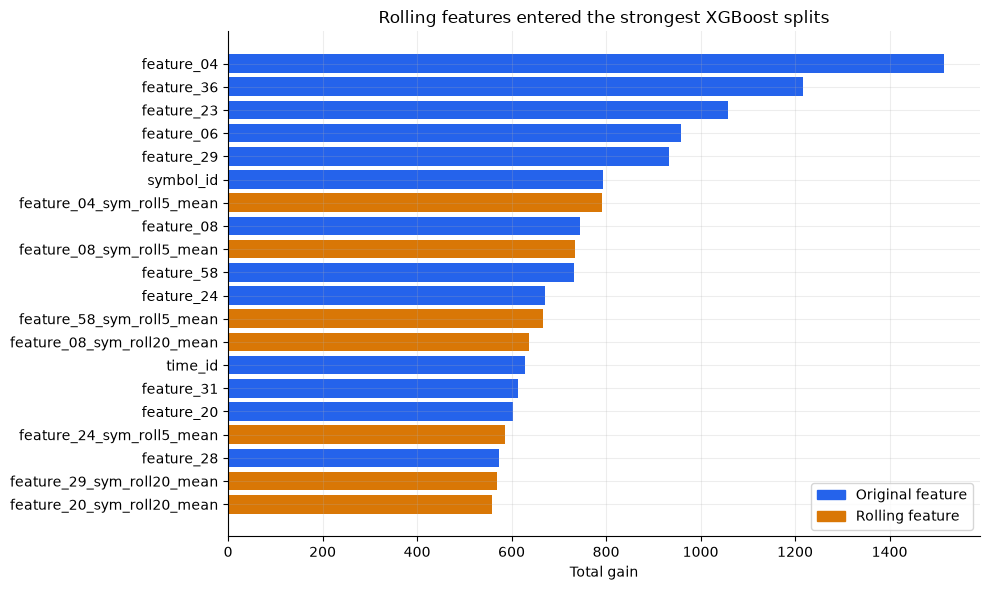

In [9]:
rolling_importance = pd.read_csv(MODEL_DIR / 'xgboost/top20_rolling_xgb/best_feature_importance.csv').head(20).copy()
rolling_importance['kind'] = np.where(rolling_importance['feature'].str.contains('_roll'), 'Rolling feature', 'Original feature')
view = rolling_importance.sort_values('importance_gain')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(view['feature'], view['importance_gain'], color=view['kind'].map({'Rolling feature': ORANGE, 'Original feature': BLUE}))
ax.set_xlabel('Total gain')
ax.set_title('Rolling features entered the strongest XGBoost splits')
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=ORANGE)]
ax.legend(handles, ['Original feature', 'Rolling feature'])
plt.tight_layout()
plt.show()

Rolling features improved LightGBM by 5.5% and XGBoost by 1.2% relative to their top-20 validation scores. Several lagged means appeared among XGBoost's strongest features, so the improvement was not merely from adding unused columns.

There are two recorded XGBoost validation values. The training report's 0.005567 uses only trees through the best early-stopping iteration. The later ensemble report reloads the saved booster and uses all stored trees, giving 0.004963 validation and 0.004996 test. Final comparisons below use the latter saved-model evaluation because it is the prediction path actually used by the ensembles.

## 6. Initial neural models

We standardized numeric inputs using training-set means and standard deviations, then trained two neural baselines on the same 60 inputs. The MLP used hidden layers `[256, 128]`; learned embeddings turned `symbol_id` and `time_id` categories into compact vectors. The GRU+MLP additionally summarized up to 16 earlier rows from the same symbol before combining that history with current inputs.

Both used AdamW and weighted mean squared error, $\sum_i w_i(\hat y_i-y_i)^2/\sum_i w_i$. Squaring makes large mistakes especially costly and matches the numerator of weighted $R^2$. The training loss and validation $R^2$ are different scales; their opposite directions diagnose generalization failure.

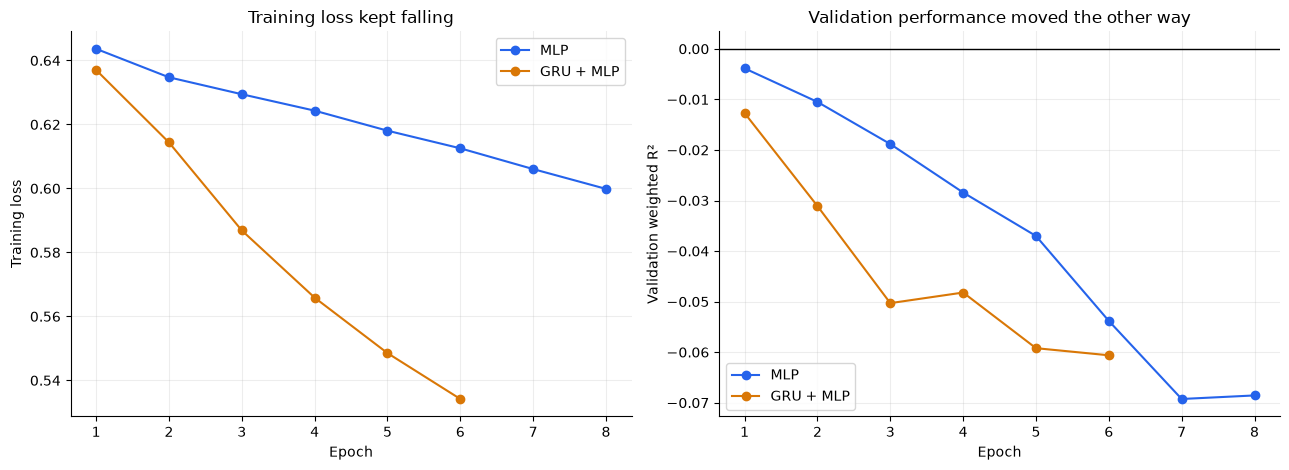

In [10]:
mlp = load_json('train_mlp_rolling_report.json')
gru = load_json('train_gru_mlp_rolling_report.json')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for report, label, color in [(mlp, 'MLP', BLUE), (gru, 'GRU + MLP', ORANGE)]:
    history = pd.DataFrame(report['history'])
    axes[0].plot(history['epoch'], history['train_loss'], marker='o', label=label, color=color)
    axes[1].plot(history['epoch'], history['valid_weighted_r2'], marker='o', label=label, color=color)
axes[0].set_title('Training loss kept falling')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training loss')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Validation performance moved the other way')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation weighted R²')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

This is clear overfitting: the networks fit the training period more closely while becoming worse on later dates. The MLP's best validation score was -0.003860 and the GRU+MLP's was -0.012707, both at epoch 1. The extra sequence model added capacity but did not extract stable temporal signal.

### Online updates

We also simulated predict-then-update learning. For each date, the model first predicted all rows without seeing that date's targets; it then made one training pass on the revealed date before moving forward. The online learning rates were much smaller than the original rates (`2e-5` for MLP and `1e-5` for GRU+MLP). The intent was regime adaptation without full retraining.

,model,valid,test
0,MLP,-0.003860,-0.006744
1,GRU + MLP,-0.012707,-0.014378
2,Online MLP,-0.146223,-0.062946
3,Online GRU + MLP,-0.105476,-0.082004


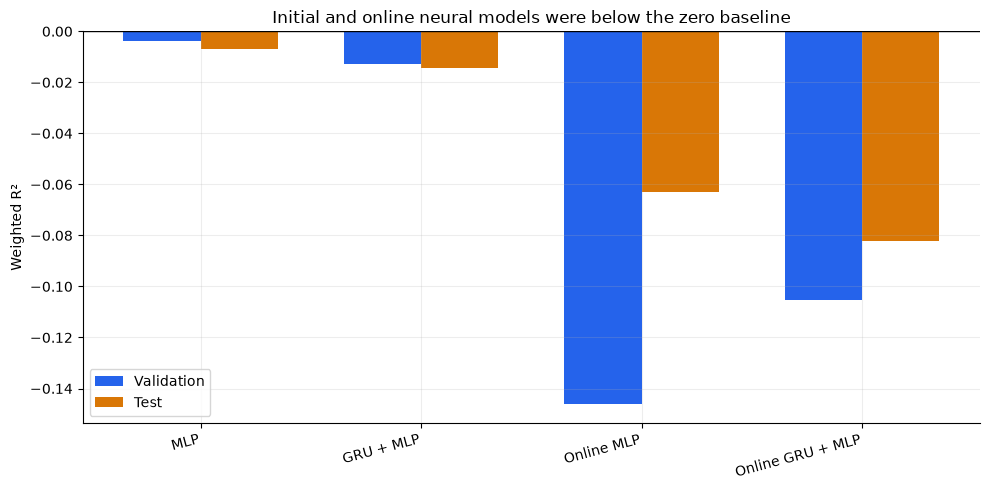

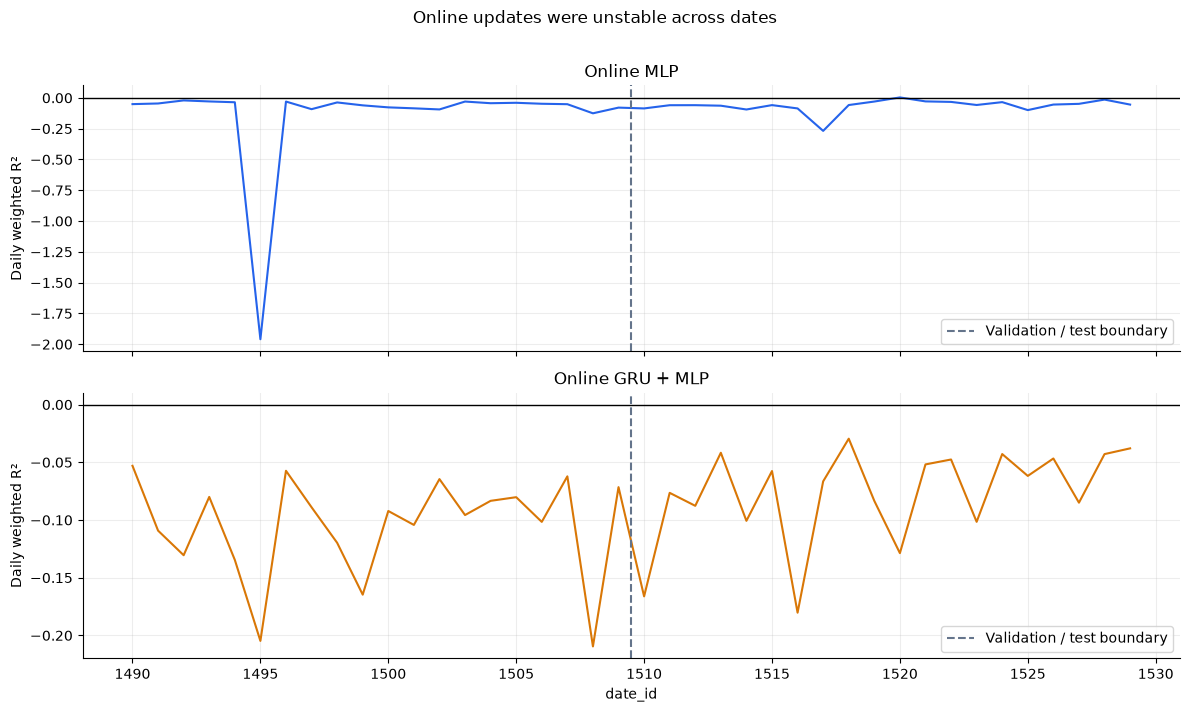

In [11]:
online_mlp = load_json('train_online_mlp_rolling_report.json')
online_gru = load_json('train_online_gru_mlp_rolling_report.json')

neural_initial = pd.DataFrame([
    {'model': 'MLP', 'valid': mlp['valid_weighted_r2'], 'test': mlp['test_weighted_r2']},
    {'model': 'GRU + MLP', 'valid': gru['valid_weighted_r2'], 'test': gru['test_weighted_r2']},
    {'model': 'Online MLP', 'valid': online_mlp['valid_online_weighted_r2'], 'test': online_mlp['test_online_weighted_r2']},
    {'model': 'Online GRU + MLP', 'valid': online_gru['valid_online_weighted_r2'], 'test': online_gru['test_online_weighted_r2']},
])
display(neural_initial.style.format({'valid': '{:.6f}', 'test': '{:.6f}'}))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(neural_initial))
width = 0.35
ax.bar(x - width / 2, neural_initial['valid'], width, label='Validation', color=BLUE)
ax.bar(x + width / 2, neural_initial['test'], width, label='Test', color=ORANGE)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x, neural_initial['model'], rotation=15, ha='right')
ax.set_ylabel('Weighted R²')
ax.set_title('Initial and online neural models were below the zero baseline')
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, report, label, color in [
    (axes[0], online_mlp, 'Online MLP', BLUE),
    (axes[1], online_gru, 'Online GRU + MLP', ORANGE),
]:
    daily = pd.DataFrame(report['date_scores'])
    ax.plot(daily['date_id'], daily['weighted_r2'], color=color, linewidth=1.5)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(1509.5, color=GRAY, linestyle='--', label='Validation / test boundary')
    ax.set_ylabel('Daily weighted R²')
    ax.set_title(label)
    ax.legend()
axes[1].set_xlabel('date_id')
fig.suptitle('Online updates were unstable across dates', y=1.01)
plt.tight_layout()
plt.show()

Online MLP validation fell to -0.146223 and online GRU+MLP to -0.105476. A fixed learning rate and one update per date were too aggressive for a noisy, shifting target, so online learning was excluded from the final focused ensemble.

## 7. Neural regularization experiments

The next sweep isolated several ways to reduce overfitting:

- **Smaller networks:** fewer hidden units reduce the number of patterns the model can memorize.
- **Dropout:** randomly removes 20-30% of hidden activations during training, so predictions cannot rely on one path.
- **Weight decay:** AdamW penalizes large parameters; larger decay means stronger regularization.
- **LayerNorm:** replaced BatchNorm so normalization did not depend on noisy batch statistics.
- **No embeddings:** tested whether symbol/time identity encouraged memorization instead of generalization.
- **Early stopping and gradient clipping:** stopped after two non-improving epochs and capped gradient norm at 1.

We compared weighted MSE with **Huber loss**. For error $e$, Huber is $0.5e^2$ when $|e|\leq\delta$ and $\delta(|e|-0.5\delta)$ otherwise, with $\delta=0.5$. It behaves like MSE for small errors but only grows linearly for outliers. We also selected a prediction multiplier from 0.25 to 1.0 on validation. This **shrinkage** pulls forecasts toward zero when the network gets direction roughly right but predicts magnitudes that are too large.

,model,hidden,loss,huber_delta,use_embeddings,dropout,lr,weight_decay,best_epoch,best_shrink,valid_weighted_r2,test_weighted_r2
0,small_no_embed,"[128, 64]",mse,nan,False,0.250000,3e-04,1e-03,3,0.750000,0.005661,0.001942
1,small_huber,"[128, 64]",huber,0.500000,True,0.300000,3e-04,1e-03,5,0.750000,0.005396,0.001465
2,small_mse,"[128, 64]",mse,nan,True,0.250000,3e-04,1e-03,4,0.750000,0.005264,0.002715
3,tiny_mse,"[64, 32]",mse,nan,True,0.200000,3e-04,1e-03,5,0.500000,0.004512,0.001730
4,linear_strong_decay,[],huber,0.500000,True,0.000000,1e-04,1e-02,5,0.500000,0.003293,0.000922


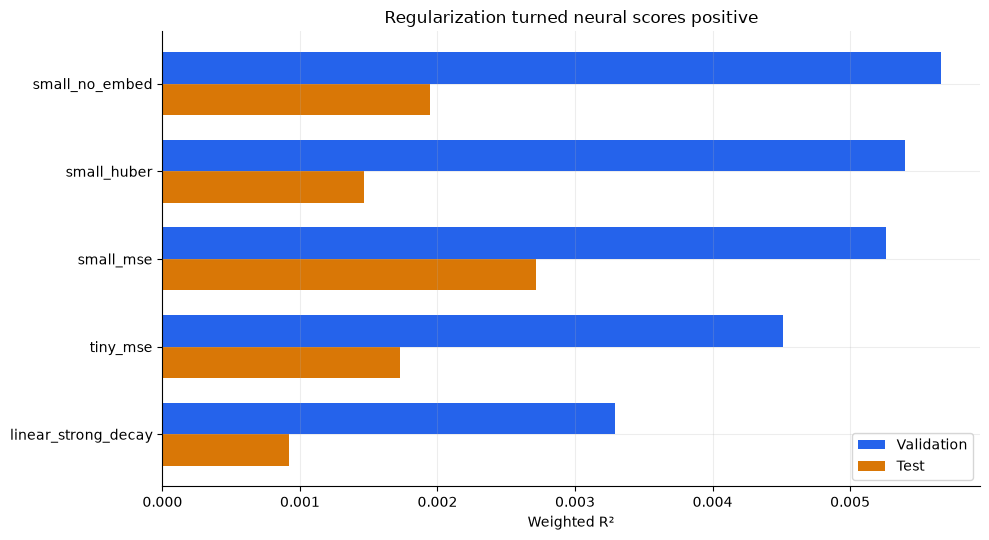

In [12]:
sweep = pd.read_csv(MODEL_DIR / 'neural/regularized_mlp_sweep/summary.csv').sort_values('valid_weighted_r2', ascending=True)
sweep_cols = ['model', 'hidden', 'loss', 'huber_delta', 'use_embeddings', 'dropout', 'lr', 'weight_decay', 'best_epoch', 'best_shrink', 'valid_weighted_r2', 'test_weighted_r2']
display(sweep[sweep_cols].sort_values('valid_weighted_r2', ascending=False).style.format({'valid_weighted_r2': '{:.6f}', 'test_weighted_r2': '{:.6f}', 'lr': '{:.0e}', 'weight_decay': '{:.0e}'}))

fig, ax = plt.subplots(figsize=(10, 5.5))
y = np.arange(len(sweep))
height = 0.36
ax.barh(y + height / 2, sweep['valid_weighted_r2'], height, label='Validation', color=BLUE)
ax.barh(y - height / 2, sweep['test_weighted_r2'], height, label='Test', color=ORANGE)
ax.set_yticks(y, sweep['model'])
ax.set_xlabel('Weighted R²')
ax.set_title('Regularization turned neural scores positive')
ax.legend()
plt.tight_layout()
plt.show()

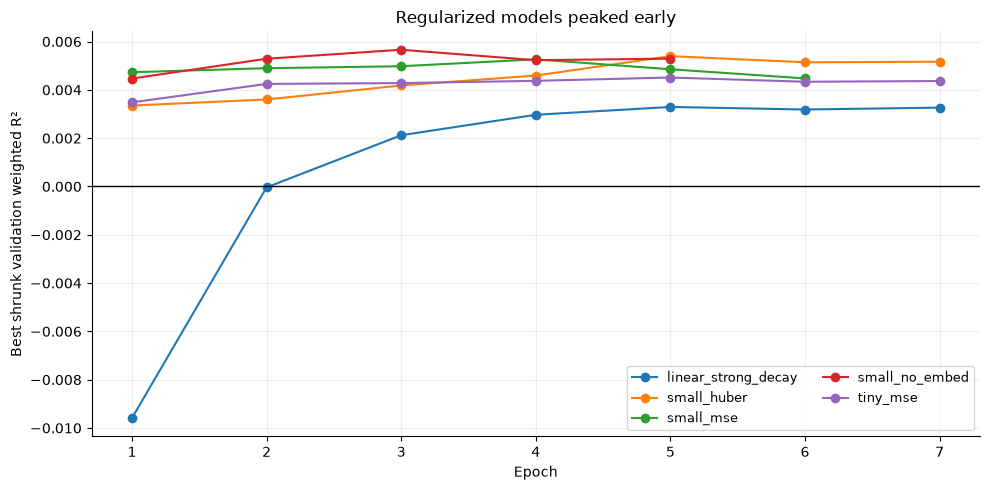

In [13]:
sweep_history = pd.read_csv(MODEL_DIR / 'neural/regularized_mlp_sweep/history.csv')
fig, ax = plt.subplots(figsize=(10, 5))
for model, frame in sweep_history.groupby('model'):
    ax.plot(frame['epoch'], frame['best_shrunk_valid_weighted_r2'], marker='o', label=model)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Epoch')
ax.set_ylabel('Best shrunk validation weighted R²')
ax.set_title('Regularized models peaked early')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

The strongest first-sweep model was a `[128, 64]` MLP without symbol/time embeddings. It reached 0.005661 validation $R^2$, compared with -0.003860 for the original MLP. Huber loss was useful but not best: `small_huber` reached 0.005396 validation and 0.001465 test. The strongly regularized linear model was weakest, showing that some nonlinear capacity was still necessary. Across the sweep, models peaked around epochs 3-5 and shrank predictions to 50-75% of raw magnitude.

### Focused sweep across seeds

We then ran five `[128, 64]` MLP settings with seeds 42, 202, and 777 (15 runs total): no embeddings; no embeddings with dropout raised from 0.25 to 0.35; no embeddings with weight decay raised from `1e-3` to `3e-3`; embeddings with the standard learning rate; and embeddings with learning rate reduced from `3e-4` to `1e-4`. Repeating seeds separates a stable design choice from a lucky initialization. The shrinkage grid was refined to 0.40-1.00.

,valid_mean,valid_std,test_mean,test_std
base_name,,,,
small_no_embed_more_dropout,0.005592,0.000126,0.002738,0.000630
small_no_embed_more_decay,0.005459,0.000103,0.002974,0.000611
small_no_embed,0.005458,0.000102,0.002973,0.000611
small_mse,0.005193,0.000504,0.002096,0.000488
small_mse_low_lr,0.005160,0.000443,0.001863,0.000866


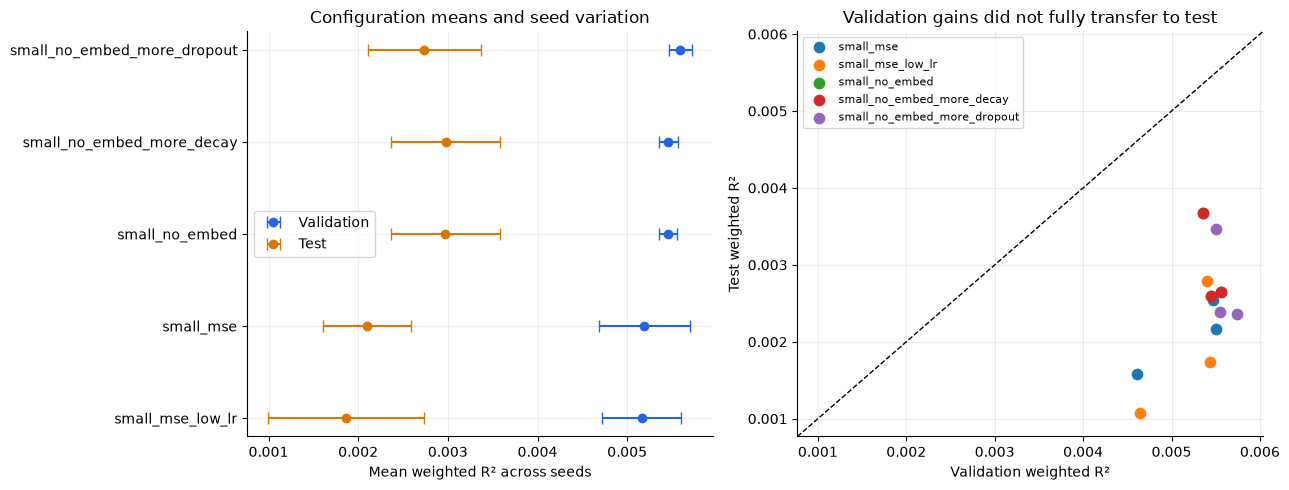

In [14]:
focused = pd.read_csv(MODEL_DIR / 'neural/regularized_mlp_focused/summary.csv')
focused_group = focused.groupby('base_name').agg(
    valid_mean=('valid_weighted_r2', 'mean'),
    valid_std=('valid_weighted_r2', 'std'),
    test_mean=('test_weighted_r2', 'mean'),
    test_std=('test_weighted_r2', 'std'),
).sort_values('valid_mean', ascending=False)
display(focused_group.style.format('{:.6f}'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = focused_group.index[::-1]
axes[0].errorbar(focused_group.loc[order, 'valid_mean'], order, xerr=focused_group.loc[order, 'valid_std'], fmt='o', color=BLUE, capsize=4, label='Validation')
axes[0].errorbar(focused_group.loc[order, 'test_mean'], order, xerr=focused_group.loc[order, 'test_std'], fmt='o', color=ORANGE, capsize=4, label='Test')
axes[0].set_xlabel('Mean weighted R² across seeds')
axes[0].set_title('Configuration means and seed variation')
axes[0].legend()

for base_name, frame in focused.groupby('base_name'):
    axes[1].scatter(frame['valid_weighted_r2'], frame['test_weighted_r2'], s=55, label=base_name)
lim_min = min(focused['valid_weighted_r2'].min(), focused['test_weighted_r2'].min()) - 0.0003
lim_max = max(focused['valid_weighted_r2'].max(), focused['test_weighted_r2'].max()) + 0.0003
axes[1].plot([lim_min, lim_max], [lim_min, lim_max], color='black', linestyle='--', linewidth=1)
axes[1].set_xlim(lim_min, lim_max)
axes[1].set_ylim(lim_min, lim_max)
axes[1].set_xlabel('Validation weighted R²')
axes[1].set_ylabel('Test weighted R²')
axes[1].set_title('Validation gains did not fully transfer to test')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

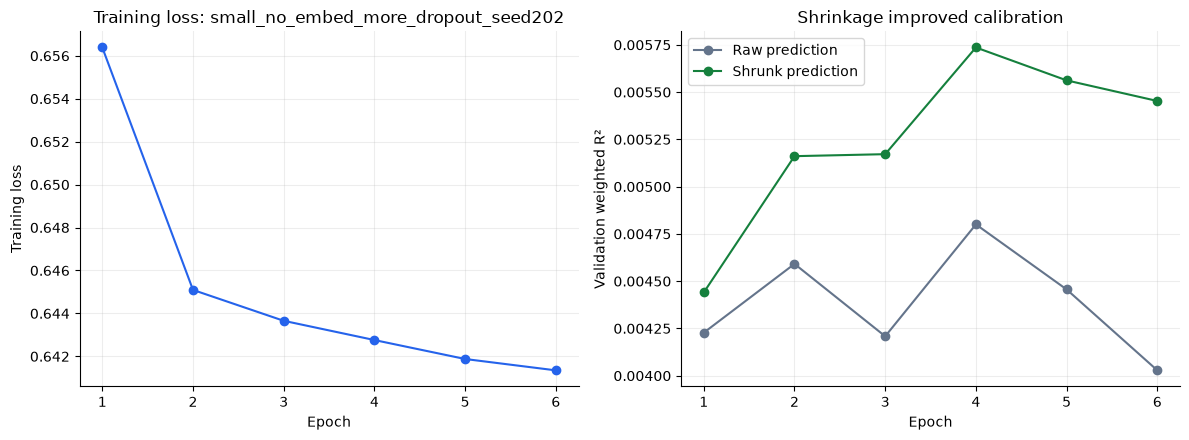

In [15]:
focused_history = pd.read_csv(MODEL_DIR / 'neural/regularized_mlp_focused/history.csv')
best_name = focused.sort_values('valid_weighted_r2', ascending=False).iloc[0]['model']
best_history = focused_history[focused_history['model'] == best_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(best_history['epoch'], best_history['train_loss'], marker='o', color=BLUE)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training loss')
axes[0].set_title(f'Training loss: {best_name}')
axes[1].plot(best_history['epoch'], best_history['valid_weighted_r2'], marker='o', label='Raw prediction', color=GRAY)
axes[1].plot(best_history['epoch'], best_history['best_shrunk_valid_weighted_r2'], marker='o', label='Shrunk prediction', color=GREEN)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation weighted R²')
axes[1].set_title('Shrinkage improved calibration')
axes[1].legend()
plt.tight_layout()
plt.show()

The best validation run used no embeddings and higher dropout (`0.35`), reaching 0.005736. However, it scored only 0.002365 on test. The strongest test run used more weight decay and seed 42, scoring 0.003679. Regularization fixed the obvious overfitting, but the remaining validation-test gap showed that neural selection was still sensitive to regime and seed.

## 8. Ensembles

Ensembling can help when models make different errors. The first blend searched non-negative weights in 5% steps across rolling XGBoost, original MLP, GRU+MLP, and both online models. The second selected the eight strongest focused MLPs by validation score, averaged them to reduce seed variance, then searched XGBoost-versus-MLP weights in 2.5% steps. All weights were selected on validation; test was used only to report the chosen blend.

split,test,valid
model,,
ensemble,0.004425,0.006523
focused_mlp_mean,0.003024,0.005984
xgb,0.004996,0.004963


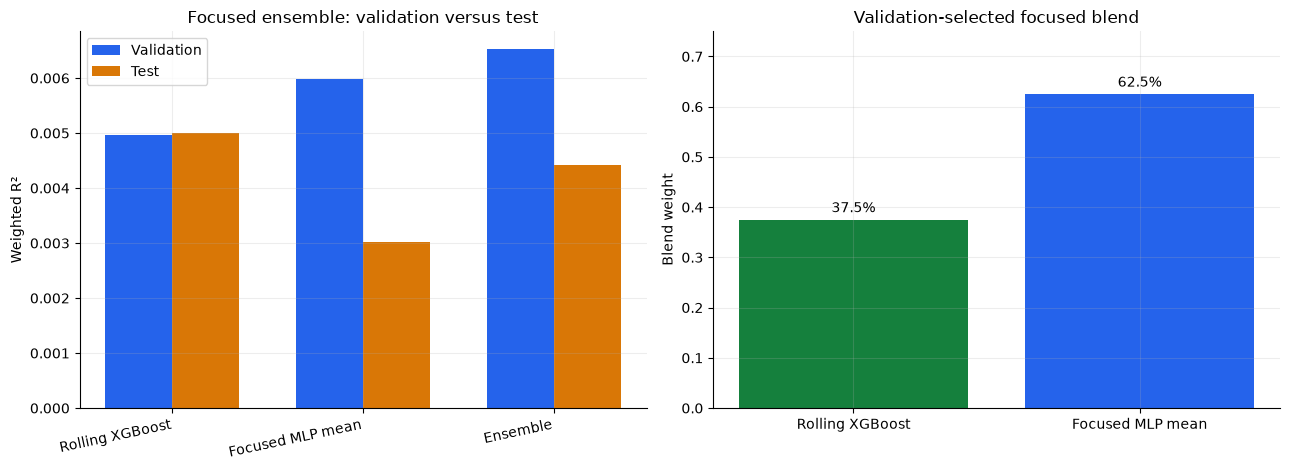

In [16]:
rolling_ensemble = load_json('ensemble_rolling_report.json')
focused_ensemble = load_json('ensemble_focused_mlp_xgb_report.json')

ensemble_scores = pd.DataFrame(focused_ensemble['scores'])
display(ensemble_scores.pivot(index='model', columns='split', values='weighted_r2').style.format('{:.6f}'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
score_pivot = ensemble_scores.pivot(index='model', columns='split', values='weighted_r2').reindex(['xgb', 'focused_mlp_mean', 'ensemble'])
x = np.arange(len(score_pivot))
width = 0.35
axes[0].bar(x - width / 2, score_pivot['valid'], width, label='Validation', color=BLUE)
axes[0].bar(x + width / 2, score_pivot['test'], width, label='Test', color=ORANGE)
axes[0].set_xticks(x, ['Rolling XGBoost', 'Focused MLP mean', 'Ensemble'], rotation=12, ha='right')
axes[0].set_ylabel('Weighted R²')
axes[0].set_title('Focused ensemble: validation versus test')
axes[0].legend()

weights = focused_ensemble['best_weights']
weight_names = ['Rolling XGBoost', 'Focused MLP mean']
weight_values = [weights['w_xgb_pred'], weights['w_focused_mlp_mean_pred']]
bars = axes[1].bar(weight_names, weight_values, color=[GREEN, BLUE])
axes[1].bar_label(bars, labels=[f'{v:.1%}' for v in weight_values], padding=3)
axes[1].set_ylim(0, 0.75)
axes[1].set_ylabel('Blend weight')
axes[1].set_title('Validation-selected focused blend')
plt.tight_layout()
plt.show()

split,test,valid
model,,
xgb,0.004996,0.004963
mlp,-0.006744,-0.003860
gru_mlp,-0.014378,-0.012707
online_gru_mlp,-0.082004,-0.105476
online_mlp,-0.062946,-0.146223


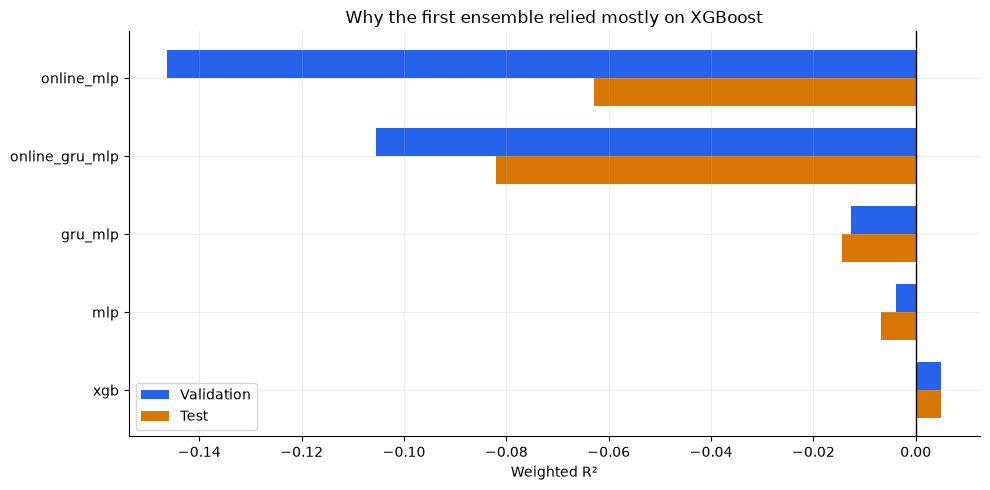

In [17]:
all_neural_scores = pd.DataFrame(rolling_ensemble['scores'])
components = all_neural_scores[all_neural_scores['model'].isin(['xgb', 'mlp', 'gru_mlp', 'online_mlp', 'online_gru_mlp'])]
component_pivot = components.pivot(index='model', columns='split', values='weighted_r2').sort_values('valid', ascending=False)
display(component_pivot.style.format('{:.6f}'))

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(component_pivot))
height = 0.36
ax.barh(y + height / 2, component_pivot['valid'], height, label='Validation', color=BLUE)
ax.barh(y - height / 2, component_pivot['test'], height, label='Test', color=ORANGE)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(y, component_pivot.index)
ax.set_xlabel('Weighted R²')
ax.set_title('Why the first ensemble relied mostly on XGBoost')
ax.legend()
plt.tight_layout()
plt.show()

The focused blend used 37.5% rolling XGBoost and 62.5% focused MLP mean. It produced the best validation score, 0.006523, but only 0.004425 on test. The earlier mixed ensemble used 80% XGBoost, 15% MLP, 5% online GRU+MLP, and zero weight on the other two neural models; it reached 0.005796 validation and 0.004597 test. In both cases, validation favored neural diversity more than the later test period did, so neither blend beat standalone XGBoost on test.

## 9. Final comparison

,model,valid,test
9,Focused MLP + XGB ensemble,0.006523,0.004425
7,Focused MLP mean,0.005984,0.003024
8,Mixed ensemble,0.005796,0.004597
6,Best focused MLP,0.005736,0.002365
1,Top-20 XGBoost,0.005500,not recorded
3,Rolling XGBoost,0.004963,0.004996
2,Rolling LightGBM,0.004498,not recorded
0,Top-20 LightGBM,0.004264,not recorded
4,Original MLP,-0.003860,-0.006744
5,Original GRU + MLP,-0.012707,-0.014378


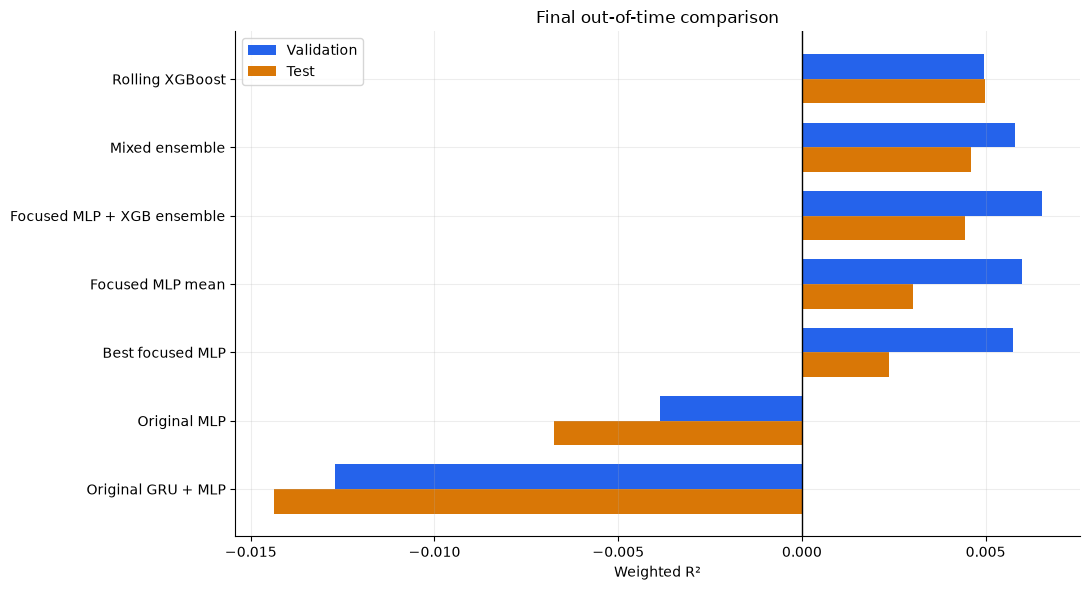

In [18]:
final_scores = pd.DataFrame([
    {'model': 'Top-20 LightGBM', 'valid': top20_lgbm['best']['valid_weighted_r2'], 'test': np.nan},
    {'model': 'Top-20 XGBoost', 'valid': top20_xgb['best']['valid_weighted_r2'], 'test': np.nan},
    {'model': 'Rolling LightGBM', 'valid': rolling_lgbm['best']['valid_weighted_r2'], 'test': np.nan},
    {'model': 'Rolling XGBoost', 'valid': 0.00496300087083712, 'test': 0.004995555865312973},
    {'model': 'Original MLP', 'valid': mlp['valid_weighted_r2'], 'test': mlp['test_weighted_r2']},
    {'model': 'Original GRU + MLP', 'valid': gru['valid_weighted_r2'], 'test': gru['test_weighted_r2']},
    {'model': 'Best focused MLP', 'valid': focused['valid_weighted_r2'].max(), 'test': focused.sort_values('valid_weighted_r2', ascending=False).iloc[0]['test_weighted_r2']},
    {'model': 'Focused MLP mean', 'valid': 0.005984495775883114, 'test': 0.0030242803020824605},
    {'model': 'Mixed ensemble', 'valid': 0.005795734651805495, 'test': 0.004597302726232044},
    {'model': 'Focused MLP + XGB ensemble', 'valid': 0.00652309456115141, 'test': 0.004425163157584344},
])
display(final_scores.sort_values('valid', ascending=False).style.format({'valid': '{:.6f}', 'test': '{:.6f}'}, na_rep='not recorded'))

plot_scores = final_scores.dropna(subset=['test']).sort_values('test')
fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(plot_scores))
height = 0.36
ax.barh(y + height / 2, plot_scores['valid'], height, label='Validation', color=BLUE)
ax.barh(y - height / 2, plot_scores['test'], height, label='Test', color=ORANGE)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(y, plot_scores['model'])
ax.set_xlabel('Weighted R²')
ax.set_title('Final out-of-time comparison')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Limits of the evidence

- Results cover one partition and complete rows only, so they may not represent the full competition period or missing-data regimes.
- The same validation dates guided feature selection, hyperparameters, shrinkage, seeds, and blend weights. Trying many ideas can overfit validation even without training on it directly.
- Test scores were inspected throughout the neural experiments. The test period is therefore a later chronological comparison, not a pristine unbiased estimate of future performance.
- The saved XGBoost ensemble path used all stored trees rather than only the best early-stopping iteration. Its final reported score describes the artifact actually ensembled, but the implementation should be standardized before a competition submission.

## Conclusion

The project moved from a memory-safe clean partition to chronological tree baselines, then added lagged symbol-level structure and neural experiments. Rolling features helped both tree families, and XGBoost was consistently stronger than LightGBM. The first neural models overfit immediately; smaller networks, dropout, weight decay, removal of embeddings, early stopping, multiple seeds, and prediction shrinkage made MLP scores positive and competitive on validation. GRU complexity and online updates did not help.

The focused neural ensemble achieved the highest validation score, but that gain weakened on the later test period. Rolling XGBoost finished as the strongest test model at weighted $R^2=0.004996$. The main lesson is that validation gains in this noisy time series only count when they survive a later market regime.